# **Notes to use this notebook:**
1. This notebook has been created and run successfully in Colab.
2. This notebool will read DCC Register, clean data, update data, and generate reports accordingly.
3. Excel output file will be also generated.

# Step 1: To Upload DCC Register Excel file.
Confirm the successful upload of "Submittal and RFI Tracker Lists (1).xlsx", the listing of its sheet names, the reading of the "Prolog Submittals " worksheet with the 5th row as the header, and the application of forward-fill to handle empty cells, then offer to assist with further analysis or tasks based on the processed data.

## Upload Excel File

### Subtask:
Upload a single Excel file from your local drive.


**Reasoning**:
The user wants to upload an Excel file from their local drive using `google.colab.files.upload()`. This command will open a file selection dialog in the Colab environment.



In [1]:
from google.colab import files

print("Please upload the 'Submittal and RFI Tracker Lists.xlsx' file.")
uploaded = files.upload()
uploaded_file_name = list(uploaded.keys())[0]
print(f"File '{uploaded_file_name}' uploaded successfully.")

Please upload the 'Submittal and RFI Tracker Lists.xlsx' file.


Saving Submittal and RFI Tracker Lists.xlsx to Submittal and RFI Tracker Lists.xlsx
File 'Submittal and RFI Tracker Lists.xlsx' uploaded successfully.


**Reasoning**:
The Excel file has been successfully uploaded. The next step is to list the sheet names within the uploaded Excel file to understand its structure.



In [2]:
import pandas as pd

xls = pd.ExcelFile(uploaded_file_name)
sheet_names = xls.sheet_names
print("Sheet names in the Excel file:")
for i, name in enumerate(sheet_names):
    print(f"{i+1}. {name}")

Sheet names in the Excel file:
1. Summary Chart
2. Delay Analysis
3. Delay in Response
4. Prolog Submittals 
5. RFIs
6. Doc Typ
7. Discipline
8. Project Prefix querries
9. Public Holiday
10. Project Prefix
11. Status Legend
12. Testing
13. draft


/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'Delay in Response'!$A:$P.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


## Select and Load the Worksheet

Now you can interactively select any other worksheet from the uploaded Excel file. The selected sheet will be loaded into a new DataFrame (`df_selected_sheet`), with the 5th row as the header and forward-fill applied to handle empty cells.

Notes: 'Prolog Submittals ' shall be selected.

In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create a dropdown widget for sheet selection
sheet_selector = widgets.Dropdown(
    options=sheet_names,
    description='Select a different sheet:',
    disabled=False,
    value=None # Set initial value to None so the user explicitly selects
)

def on_sheet_select(change):
    clear_output(wait=True)
    global selected_sheet # Declare selected_sheet as global
    selected_sheet = change.new
    if selected_sheet:
        try:
            global df_selected_sheet_filled # Declare df_selected_sheet_filled as global
            # Load the selected sheet into a DataFrame, applying header=4 and ffill
            df_selected_sheet = pd.read_excel(uploaded_file_name, sheet_name=selected_sheet, header=4)
            df_selected_sheet_filled = df_selected_sheet.ffill()
            print(f"\nSuccessfully loaded and forward-filled data from worksheet: '{selected_sheet}'")
            print("First 5 rows of the processed DataFrame for the selected sheet:")
            display(df_selected_sheet_filled.head())
        except Exception as e:
            print(f"Error loading sheet '{selected_sheet}': {e}")
    else:
        print("Please select a sheet.")

sheet_selector.observe(on_sheet_select, names='value')

print("Please select a sheet from the dropdown below:")
display(sheet_selector)

# Note: df_selected_sheet_filled will be updated each time a new selection is made
# You can then use df_selected_sheet_filled for further analysis on the newly selected sheet.

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'Delay in Response'!$A:$P.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)



Successfully loaded and forward-filled data from worksheet: 'Prolog Submittals '
First 5 rows of the processed DataFrame for the selected sheet:


,Doc ID,1st Submission\nDate,Latest Submission Date,Latest Revision,Latest Approval Status,Approval Code,# of Submissions,Prolog Submittal No.,Submitted by,Document Title,...,Remark,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,FOR FOLLOW UP,Unnamed: 48,Unnamed: 49,Unnamed: 50
0,131242-WST00-PP-PM-0001,2023-05-15,2024-05-13,Rev.1,Approved with Comments,AWC,2.0,1.0,Soe Myat,Project Quality Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,Soe Myat,NaN,1.0,1.0
1,131242-WST00-PP-PM-0001,2023-05-15,2024-05-13,Rev.1,Approved with Comments,AWC,2.0,1.0,Radha,Project Quality Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,Radha,NaN,1.0,0.0
2,131242-WST00-PP-PC-0001,2023-05-15,2023-05-15,Rev.0,Approved with Comments,AWC,1.0,2.0,Shena,Project Risk Management Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,Shena,NaN,1.0,1.0
3,131242-WSW41-PP-PC-0001,2023-09-05,2023-10-30,Rev.2,Approved,APP,2.0,2.0,Max/Edwin,Project Risk Management Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,Max/Edwin,NaN,1.0,1.0
4,#000002.0_ Reply_2023 08 31----,2023-09-05,2023-09-05,Rev.,Approved with Comments,AWC,1.0,2.0,Max/Edwin,Project Risk Management Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,Max/Edwin,NaN,1.0,1.0


## Consolidate Data Loading and Cleaning

### Subtask:
Consolidate the steps for loading data with a column limit, removing empty rows, and removing empty columns into a single code cell. The resulting DataFrame will be named `df_cleaned_and_filtered`.

In [8]:
import string

# Generate a list of Excel column names up to 'AP'
alphabet = list(string.ascii_uppercase)
excel_cols = []
for i in range(2):
    for char in alphabet:
        if i == 0:
            excel_cols.append(char)
        else:
            excel_cols.append(alphabet[i-1] + char)
        if (i*26 + alphabet.index(char)) >= 41: # 'AP' is the 42nd column, index 41
            break

# 1. Load the selected sheet into a DataFrame, applying header=4, ffill, and limiting columns by integer index
df_cleaned_and_filtered = pd.read_excel(
    uploaded_file_name,
    sheet_name=selected_sheet,
    header=4,
    usecols=range(len(excel_cols)) # Use integer indices to select columns by position
)
df_cleaned_and_filtered = df_cleaned_and_filtered.ffill()

# 2. Remove empty rows
df_cleaned_and_filtered = df_cleaned_and_filtered.dropna(how='all')

# 3. Remove empty columns
df_cleaned_and_filtered = df_cleaned_and_filtered.dropna(axis=1, how='all')

print(f"\nSuccessfully loaded, forward-filled, and cleaned data from worksheet: '{selected_sheet}' up to column 'AP'.")
print("First 5 rows of the consolidated and cleaned DataFrame:")
display(df_cleaned_and_filtered.head())

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'Delay in Response'!$A:$P.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)



Successfully loaded, forward-filled, and cleaned data from worksheet: 'Prolog Submittals ' up to column 'AP'.
First 5 rows of the consolidated and cleaned DataFrame:


,Doc ID,1st Submission\nDate,Latest Submission Date,Latest Revision,Latest Approval Status,Approval Code,# of Submissions,Prolog Submittal No.,Submitted by,Document Title,...,Actual Date S.O. Response,SO Response Variance,SO Review Status,To Resubmit (Yes/No),Date CES to Response\n(14 Working Days),Closed,Overdue to resubmit,Delays to resubmit,Target date to resubmit,Remark
0,131242-WST00-PP-PM-0001,2023-05-15,2024-05-13,Rev.1,Approved with Comments,AWC,2.0,1.0,Soe Myat,Project Quality Plan,...,2023-12-05,122,Approved with Comments,YES,2023-12-26,YES,Resubmitted,NaN,NaN,NaN
1,131242-WST00-PP-PM-0001,2023-05-15,2024-05-13,Rev.1,Approved with Comments,AWC,2.0,1.0,Radha,Project Quality Plan,...,2024-09-10,69,Approved with Comments,YES,2024-09-30,NO,Overdue,343.0,NaN,NaN
2,131242-WST00-PP-PC-0001,2023-05-15,2023-05-15,Rev.0,Approved with Comments,AWC,1.0,2.0,Shena,Project Risk Management Plan,...,2023-06-14,1,Approved with Comments,YES,2023-07-05,YES,Resubmitted,343.0,NaN,NaN
3,131242-WSW41-PP-PC-0001,2023-09-05,2023-10-30,Rev.2,Approved,APP,2.0,2.0,Max/Edwin,Project Risk Management Plan,...,2023-09-13,1,Approved with Comments,YES,2023-10-03,YES,Resubmitted,343.0,NaN,NaN
4,#000002.0_ Reply_2023 08 31----,2023-09-05,2023-09-05,Rev.,Approved with Comments,AWC,1.0,2.0,Max/Edwin,Project Risk Management Plan,...,2023-09-13,1,Approved with Comments,YES,2023-10-03,YES,Resubmitted,343.0,NaN,NaN


# Step 2: To Update Data Columns

## Re-calculate and Update 'Doc ID'

### Subtask:
Based on the formula or logic provided by the user, apply the same calculation to create or update the 'Doc ID' column in the `df_cleaned_and_filtered` DataFrame. Display the head of the DataFrame to show the updated column.


In [9]:
df_cleaned_and_filtered['Recalculated Doc ID'] = (
    df_cleaned_and_filtered['Proj. Code'].astype(str) + '-' +
    df_cleaned_and_filtered['Proj. Prefix'].astype(str) + '-' +
    df_cleaned_and_filtered['Doc Type'].astype(str) + '-' +
    df_cleaned_and_filtered['Discipline'].astype(str) + '-' +
    df_cleaned_and_filtered['Number'].astype(str)
)

print("DataFrame with 'Recalculated Doc ID' column:")
display(df_cleaned_and_filtered.head())

DataFrame with 'Recalculated Doc ID' column:


,Doc ID,1st Submission\nDate,Latest Submission Date,Latest Revision,Latest Approval Status,Approval Code,# of Submissions,Prolog Submittal No.,Submitted by,Document Title,...,SO Response Variance,SO Review Status,To Resubmit (Yes/No),Date CES to Response\n(14 Working Days),Closed,Overdue to resubmit,Delays to resubmit,Target date to resubmit,Remark,Recalculated Doc ID
0,131242-WST00-PP-PM-0001,2023-05-15,2024-05-13,Rev.1,Approved with Comments,AWC,2.0,1.0,Soe Myat,Project Quality Plan,...,122,Approved with Comments,YES,2023-12-26,YES,Resubmitted,NaN,NaN,NaN,131242-WST00-PP-PM-0001
1,131242-WST00-PP-PM-0001,2023-05-15,2024-05-13,Rev.1,Approved with Comments,AWC,2.0,1.0,Radha,Project Quality Plan,...,69,Approved with Comments,YES,2024-09-30,NO,Overdue,343.0,NaN,NaN,131242-WST00-PP-PM-0001
2,131242-WST00-PP-PC-0001,2023-05-15,2023-05-15,Rev.0,Approved with Comments,AWC,1.0,2.0,Shena,Project Risk Management Plan,...,1,Approved with Comments,YES,2023-07-05,YES,Resubmitted,343.0,NaN,NaN,131242-WST00-PP-PC-0001
3,131242-WSW41-PP-PC-0001,2023-09-05,2023-10-30,Rev.2,Approved,APP,2.0,2.0,Max/Edwin,Project Risk Management Plan,...,1,Approved with Comments,YES,2023-10-03,YES,Resubmitted,343.0,NaN,NaN,131242-WSW41-PP-PC-0001
4,#000002.0_ Reply_2023 08 31----,2023-09-05,2023-09-05,Rev.,Approved with Comments,AWC,1.0,2.0,Max/Edwin,Project Risk Management Plan,...,1,Approved with Comments,YES,2023-10-03,YES,Resubmitted,343.0,NaN,NaN,#000002.0_ Reply_2023 08 31-WSW41-PP-PC-0001


**Reasoning**:
To validate the accuracy of the inferred formula, I need to compare the newly created 'Recalculated Doc ID' with the original 'Doc ID' column. This comparison will help determine if the inferred formula correctly reproduces the original 'Doc ID' values.



In [10]:
mismatched_doc_ids = df_cleaned_and_filtered[df_cleaned_and_filtered['Doc ID'] != df_cleaned_and_filtered['Recalculated Doc ID']]

total_rows = len(df_cleaned_and_filtered)
matches = total_rows - len(mismatched_doc_ids)
match_percentage = (matches / total_rows) * 100
mismatch_percentage = (len(mismatched_doc_ids) / total_rows) * 100

print(f"Total rows: {total_rows}")
print(f"Matching 'Doc ID' and 'Recalculated Doc ID': {matches} ({match_percentage:.2f}%)")
print(f"Mismatched 'Doc ID' and 'Recalculated Doc ID': {len(mismatched_doc_ids)} ({mismatch_percentage:.2f}%)\n")

if not mismatched_doc_ids.empty:
    print("Sample of rows where 'Doc ID' and 'Recalculated Doc ID' do not match:")
    display(mismatched_doc_ids[['Doc ID', 'Recalculated Doc ID', 'Proj. Code', 'Proj. Prefix', 'Doc Type', 'Discipline', 'Number']].head())
else:
    print("All 'Doc ID' and 'Recalculated Doc ID' values match.")

Total rows: 11099
Matching 'Doc ID' and 'Recalculated Doc ID': 10992 (99.04%)
Mismatched 'Doc ID' and 'Recalculated Doc ID': 107 (0.96%)

Sample of rows where 'Doc ID' and 'Recalculated Doc ID' do not match:


,Doc ID,Recalculated Doc ID,Proj. Code,Proj. Prefix,Doc Type,Discipline,Number
4,#000002.0_ Reply_2023 08 31----,#000002.0_ Reply_2023 08 31-WSW41-PP-PC-0001,#000002.0_ Reply_2023 08 31,WSW41,PP,PC,0001
6,#000002.0_ Reply_2023 09 13 (002)_CES reply_20...,#000002.0_ Reply_2023 09 13 (002)_CES reply_20...,#000002.0_ Reply_2023 09 13 (002)_CES reply_20...,WSW41,PP,PC,0001
26,Reply to Comment Sheet_#000007----,Reply to Comment Sheet_#000007-WST00-PG-PC-0002,Reply to Comment Sheet_#000007,WST00,PG,PC,0002
61,131242--LT-PM-Reply to Comment Sheet_#000025,131242-WST00-LT-PM-Reply to Comment Sheet_#000025,131242,WST00,LT,PM,Reply to Comment Sheet_#000025
96,Comment Reply Sheet 08112023----,Comment Reply Sheet 08112023-WSW41-RT-PM-0002,Comment Reply Sheet 08112023,WSW41,RT,PM,0002


## Convert 'Date Submit' Column to Datetime

### Subtask:
Convert the 'Date Submit' column in `df_cleaned_and_filtered` to datetime objects, coercing any unparseable dates to `NaT`.

In [11]:
df_cleaned_and_filtered['Date Submit'] = pd.to_datetime(df_cleaned_and_filtered['Date Submit'], errors='coerce')
print("Data type of 'Date Submit' column after conversion:")
df_cleaned_and_filtered.info()

Data type of 'Date Submit' column after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11099 entries, 0 to 11098
Data columns (total 42 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   Doc ID                                                     11099 non-null  object        
 1   1st Submission
Date                                        11099 non-null  datetime64[ns]
 2   Latest Submission Date                                     11099 non-null  datetime64[ns]
 3   Latest Revision                                            11099 non-null  object        
 4   Latest Approval Status                                     11099 non-null  object        
 5   Approval Code                                              11099 non-null  object        
 6   # of Submissions                                           11099 non-null 

## Update '1st Submission Date'

### Subtask:
Update the '1st Submission Date' column in `df_cleaned_and_filtered` by finding the earliest date in 'Date Submit' for each 'Doc ID'.

In [12]:
# Calculate the earliest 'Date Submit' for each 'Doc ID'
earliest_submission_dates = df_cleaned_and_filtered.groupby('Doc ID')['Date Submit'].min().reset_index()
earliest_submission_dates.rename(columns={'Date Submit': 'Earliest Date Submit'}, inplace=True)

# Merge this back into the original DataFrame
df_cleaned_and_filtered = pd.merge(
    df_cleaned_and_filtered,
    earliest_submission_dates,
    on='Doc ID',
    how='left'
)

# Update the '1st Submission Date' column
df_cleaned_and_filtered['1st Submission\nDate'] = df_cleaned_and_filtered['Earliest Date Submit']

# Drop the temporary 'Earliest Date Submit' column
df_cleaned_and_filtered.drop(columns=['Earliest Date Submit'], inplace=True)

print("DataFrame after updating '1st Submission Date' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Date Submit', '1st Submission\nDate']].head())

DataFrame after updating '1st Submission Date' column:


,Doc ID,Date Submit,1st Submission\nDate
0,131242-WST00-PP-PM-0001,2023-05-15,2023-05-15
1,131242-WST00-PP-PM-0001,2024-05-13,2023-05-15
2,131242-WST00-PP-PC-0001,2023-05-15,2023-05-15
3,131242-WSW41-PP-PC-0001,2023-09-05,2023-09-05
4,#000002.0_ Reply_2023 08 31----,2023-09-05,2023-09-05


## Update 'Latest Submission Date'

### Subtask:
Update the 'Latest Submission Date' column in `df_cleaned_and_filtered` by finding the latest date in 'Date Submit' for each 'Doc ID'.

In [13]:
# Calculate the latest 'Date Submit' for each 'Doc ID'
latest_submission_dates = df_cleaned_and_filtered.groupby('Doc ID')['Date Submit'].max().reset_index()
latest_submission_dates.rename(columns={'Date Submit': 'Latest Date Submit'}, inplace=True)

# Merge this back into the original DataFrame
df_cleaned_and_filtered = pd.merge(
    df_cleaned_and_filtered,
    latest_submission_dates,
    on='Doc ID',
    how='left'
)

# Update the 'Latest Submission Date' column
df_cleaned_and_filtered['Latest Submission Date'] = df_cleaned_and_filtered['Latest Date Submit']

# Drop the temporary 'Latest Date Submit' column
df_cleaned_and_filtered.drop(columns=['Latest Date Submit'], inplace=True)

print("DataFrame after updating 'Latest Submission Date' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Date Submit', 'Latest Submission Date']].head())

DataFrame after updating 'Latest Submission Date' column:


,Doc ID,Date Submit,Latest Submission Date
0,131242-WST00-PP-PM-0001,2023-05-15,2024-05-13
1,131242-WST00-PP-PM-0001,2024-05-13,2024-05-13
2,131242-WST00-PP-PC-0001,2023-05-15,2023-05-15
3,131242-WSW41-PP-PC-0001,2023-09-05,2023-10-30
4,#000002.0_ Reply_2023 08 31----,2023-09-05,2023-09-05


## Update 'Latest Revision'

### Subtask:
Update the 'Latest Revision' column in `df_cleaned_and_filtered` by getting the value from the 'Rev ' column that corresponds to the 'Latest Submission Date' for each 'Doc ID', and then affix 'Rev.' to the found value.

## Update 'Latest Approval Status'

### Subtask:
Update the 'Latest Approval Status' column in `df_cleaned_and_filtered` by getting the value from the 'SO Review Status' column that corresponds to the 'Latest Submission Date' for each 'Doc ID'.

In [14]:
# Group by 'Doc ID' and find the index of the row with the maximum 'Date Submit'
idx = df_cleaned_and_filtered.groupby('Doc ID')['Date Submit'].idxmax()

# Get the 'Doc ID' and corresponding 'SO Review Status' for the latest submission date
latest_approval_status_per_doc_id = df_cleaned_and_filtered.loc[idx, ['Doc ID', 'SO Review Status']]

# Rename 'SO Review Status' column for clarity during merge
latest_approval_status_per_doc_id.rename(columns={'SO Review Status': 'Latest Approval Status Value'}, inplace=True)

# Merge this back into the main DataFrame based on 'Doc ID'
df_cleaned_and_filtered = pd.merge(
    df_cleaned_and_filtered,
    latest_approval_status_per_doc_id,
    on='Doc ID',
    how='left'
)

# Update the 'Latest Approval Status' column
df_cleaned_and_filtered['Latest Approval Status'] = df_cleaned_and_filtered['Latest Approval Status Value']

# Drop the temporary column
df_cleaned_and_filtered.drop(columns=['Latest Approval Status Value'], inplace=True)

print("DataFrame after updating 'Latest Approval Status' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Date Submit', 'Latest Submission Date', 'SO Review Status', 'Latest Approval Status']].head())

DataFrame after updating 'Latest Approval Status' column:


,Doc ID,Date Submit,Latest Submission Date,SO Review Status,Latest Approval Status
0,131242-WST00-PP-PM-0001,2023-05-15,2024-05-13,Approved with Comments,Approved with Comments
1,131242-WST00-PP-PM-0001,2024-05-13,2024-05-13,Approved with Comments,Approved with Comments
2,131242-WST00-PP-PC-0001,2023-05-15,2023-05-15,Approved with Comments,Approved with Comments
3,131242-WSW41-PP-PC-0001,2023-09-05,2023-10-30,Approved with Comments,Approved
4,#000002.0_ Reply_2023 08 31----,2023-09-05,2023-09-05,Approved with Comments,Approved with Comments


In [15]:
# Group by 'Doc ID' and find the index of the row with the maximum 'Date Submit'
idx = df_cleaned_and_filtered.groupby('Doc ID')['Date Submit'].idxmax()

# Get the 'Doc ID' and corresponding 'Rev ' for the latest submission date
latest_rev_per_doc_id = df_cleaned_and_filtered.loc[idx, ['Doc ID', 'Rev ']]

# Rename 'Rev ' column for clarity during merge
latest_rev_per_doc_id.rename(columns={'Rev ': 'Latest Rev Value'}, inplace=True)

# Merge this back into the main DataFrame based on 'Doc ID'
df_cleaned_and_filtered = pd.merge(
    df_cleaned_and_filtered,
    latest_rev_per_doc_id,
    on='Doc ID',
    how='left'
)

# Affix "Rev." and update the 'Latest Revision' column
df_cleaned_and_filtered['Latest Revision'] = 'Rev.' + df_cleaned_and_filtered['Latest Rev Value'].astype(str)

# Drop the temporary column
df_cleaned_and_filtered.drop(columns=['Latest Rev Value'], inplace=True)

print("DataFrame after updating 'Latest Revision' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Date Submit', 'Latest Submission Date', 'Rev ', 'Latest Revision']].head())

DataFrame after updating 'Latest Revision' column:


,Doc ID,Date Submit,Latest Submission Date,Rev,Latest Revision
0,131242-WST00-PP-PM-0001,2023-05-15,2024-05-13,0,Rev.1
1,131242-WST00-PP-PM-0001,2024-05-13,2024-05-13,1,Rev.1
2,131242-WST00-PP-PC-0001,2023-05-15,2023-05-15,0,Rev.0
3,131242-WSW41-PP-PC-0001,2023-09-05,2023-10-30,1,Rev.2
4,#000002.0_ Reply_2023 08 31----,2023-09-05,2023-09-05,1,Rev.1


## Update 'Approval Code'

### Subtask:
Update the 'Approval Code' column in `df_cleaned_and_filtered` based on the 'Latest Approval Status' using the following rules:
- "REJ" for "Rejected" or "Not Approved - Revise and resubmit"
- "AWC" for "Approved with Comments" or "Approved as noted"
- "APP" for "For Information" or "Approved"
- "Pending" for "Awaiting S.O.'s response", or if 'Latest Approval Status' is empty or 0
- "VOID" for "(VOID / NOT IN USE)"
- "To Check" for any other cases.

In [16]:
def get_approval_code(status):
    status_str = str(status).strip()
    if status_str in ["Rejected", "Not Approved - Revise and resubmit", "Not Approved"]:
        return "REJ"
    elif status_str in ["Approved with Comments", "Approved as noted"]:
        return "AWC"
    elif status_str in ["For Information", "Approved"]:
        return "APP"
    elif status_str in ["Awaiting S.O.'s response", "", "0"] or pd.isna(status):
        return "Pending"
    elif status_str == "(VOID / NOT IN USE)":
        return "VOID"
    else:
        return "To Check"

df_cleaned_and_filtered['Approval Code'] = df_cleaned_and_filtered['Latest Approval Status'].apply(get_approval_code)

print("DataFrame after updating 'Approval Code' column:")
display(df_cleaned_and_filtered[['Latest Approval Status', 'Approval Code']].head())

DataFrame after updating 'Approval Code' column:


,Latest Approval Status,Approval Code
0,Approved with Comments,AWC
1,Approved with Comments,AWC
2,Approved with Comments,AWC
3,Approved,APP
4,Approved with Comments,AWC


## Update '# of Submissions'

### Subtask:
Update the '# of Submissions' column in `df_cleaned_and_filtered` based on the counts of each 'Doc ID' in the DataFrame.

In [17]:
# Calculate the number of submissions for each 'Doc ID'
submission_counts = df_cleaned_and_filtered.groupby('Doc ID')['Doc ID'].transform('count')

# Update the '# of Submissions' column
df_cleaned_and_filtered['# of Submissions'] = submission_counts

print("DataFrame after updating '# of Submissions' column:")
display(df_cleaned_and_filtered[['Doc ID', '# of Submissions']].head())

DataFrame after updating '# of Submissions' column:


,Doc ID,# of Submissions
0,131242-WST00-PP-PM-0001,2
1,131242-WST00-PP-PM-0001,2
2,131242-WST00-PP-PC-0001,1
3,131242-WSW41-PP-PC-0001,2
4,#000002.0_ Reply_2023 08 31----,1


## Update 'Prolog Submittal No.'

### Subtask:
Update the 'Prolog Submittal No.' column in `df_cleaned_and_filtered` by getting unique values from 'Prolog Submittal No..1' for each 'Doc ID'. If multiple different values are found, separate them with a comma.

In [18]:
# Group by 'Doc ID' and aggregate unique 'Prolog Submittal No..1' values
consolidated_prolog_submittal_no = df_cleaned_and_filtered.groupby('Doc ID')['Prolog Submittal No..1'].agg(lambda x: ', '.join(x.dropna().astype(int).astype(str).str.zfill(6).unique().tolist())).reset_index()
consolidated_prolog_submittal_no.rename(columns={'Prolog Submittal No..1': 'Consolidated Prolog Submittal No'}, inplace=True)

# Merge this back into the main DataFrame
df_cleaned_and_filtered = pd.merge(
    df_cleaned_and_filtered,
    consolidated_prolog_submittal_no,
    on='Doc ID',
    how='left'
)

# Update the 'Prolog Submittal No.' column
df_cleaned_and_filtered['Prolog Submittal No.'] = df_cleaned_and_filtered['Consolidated Prolog Submittal No']

# Drop the temporary column
df_cleaned_and_filtered.drop(columns=['Consolidated Prolog Submittal No'], inplace=True)

print("DataFrame after updating 'Prolog Submittal No.' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Prolog Submittal No..1', 'Prolog Submittal No.']].head())

DataFrame after updating 'Prolog Submittal No.' column:


,Doc ID,Prolog Submittal No..1,Prolog Submittal No.
0,131242-WST00-PP-PM-0001,1.0,000001
1,131242-WST00-PP-PM-0001,1.0,000001
2,131242-WST00-PP-PC-0001,2.0,000002
3,131242-WSW41-PP-PC-0001,2.0,000002
4,#000002.0_ Reply_2023 08 31----,2.0,000002


## Update 'Submitted by'

### Subtask:
Update the 'Submitted by' column in `df_cleaned_and_filtered` by getting unique values from 'Document Owner' for each 'Doc ID'. If multiple different values are found, separate them with a comma.

In [19]:
# Group by 'Doc ID' and aggregate unique 'Document Owner' values
consolidated_submitted_by = df_cleaned_and_filtered.groupby('Doc ID')['Document Owner'].agg(lambda x: ', '.join(x.dropna().astype(str).unique().tolist())).reset_index()
consolidated_submitted_by.rename(columns={'Document Owner': 'Consolidated Submitted By'}, inplace=True)

# Merge this back into the main DataFrame
df_cleaned_and_filtered = pd.merge(
    df_cleaned_and_filtered,
    consolidated_submitted_by,
    on='Doc ID',
    how='left'
)

# Update the 'Submitted by' column
df_cleaned_and_filtered['Submitted by'] = df_cleaned_and_filtered['Consolidated Submitted By']

# Drop the temporary column
df_cleaned_and_filtered.drop(columns=['Consolidated Submitted By'], inplace=True)

print("DataFrame after updating 'Submitted by' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Document Owner', 'Submitted by']].head())

DataFrame after updating 'Submitted by' column:


,Doc ID,Document Owner,Submitted by
0,131242-WST00-PP-PM-0001,Soe Myat,"Soe Myat, Radha"
1,131242-WST00-PP-PM-0001,Radha,"Soe Myat, Radha"
2,131242-WST00-PP-PC-0001,Shena,Shena
3,131242-WSW41-PP-PC-0001,Max/Edwin,"Max/Edwin, Max"
4,#000002.0_ Reply_2023 08 31----,Max/Edwin,Max/Edwin


## Update 'Document Title'

### Subtask:
Update the 'Document Title' column in `df_cleaned_and_filtered` by getting unique values from 'Document Description / Drawing Title' for each 'Doc ID'. If multiple different values are found, separate them with a comma.

In [20]:
# Group by 'Doc ID' and aggregate unique 'Document Description / Drawing Title' values
consolidated_document_title = df_cleaned_and_filtered.groupby('Doc ID')['Document Description / Drawing Title'].agg(lambda x: ', '.join(x.dropna().astype(str).unique().tolist())).reset_index()
consolidated_document_title.rename(columns={'Document Description / Drawing Title': 'Consolidated Document Title'}, inplace=True)

# Merge this back into the main DataFrame
df_cleaned_and_filtered = pd.merge(
    df_cleaned_and_filtered,
    consolidated_document_title,
    on='Doc ID',
    how='left'
)

# Update the 'Document Title' column
df_cleaned_and_filtered['Document Title'] = df_cleaned_and_filtered['Consolidated Document Title']

# Drop the temporary column
df_cleaned_and_filtered.drop(columns=['Consolidated Document Title'], inplace=True)

print("DataFrame after updating 'Document Title' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Document Title', 'Document Description / Drawing Title']].head())

DataFrame after updating 'Document Title' column:


,Doc ID,Document Title,Document Description / Drawing Title
0,131242-WST00-PP-PM-0001,Project Quality Plan,Project Quality Plan
1,131242-WST00-PP-PM-0001,Project Quality Plan,Project Quality Plan
2,131242-WST00-PP-PC-0001,Project Risk Management Plan,Project Risk Management Plan
3,131242-WSW41-PP-PC-0001,Project Risk Management Plan,Project Risk Management Plan
4,#000002.0_ Reply_2023 08 31----,Project Risk Management Plan,Project Risk Management Plan


## Update 'This Revision'

### Subtask:
Update the 'This Revision' column in `df_cleaned_and_filtered` by assigning it the values from the 'Rev ' column.

In [21]:
# Update the 'This Revision' column with values from 'Rev '
df_cleaned_and_filtered['This Revision'] = df_cleaned_and_filtered['Rev ']

print("DataFrame after updating 'This Revision' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Rev ', 'This Revision']].head())

DataFrame after updating 'This Revision' column:


,Doc ID,Rev,This Revision
0,131242-WST00-PP-PM-0001,0,0
1,131242-WST00-PP-PM-0001,1,1
2,131242-WST00-PP-PC-0001,0,0
3,131242-WSW41-PP-PC-0001,1,1
4,#000002.0_ Reply_2023 08 31----,1,1


## Update 'This Submission Date'

### Subtask:
Update the 'This Submission Date' column in `df_cleaned_and_filtered` by assigning it the values from the 'Date Submit' column.

In [22]:
# Update the 'This Submission Date' column with values from 'Date Submit'
df_cleaned_and_filtered['This Submission Date'] = df_cleaned_and_filtered['Date Submit']

print("DataFrame after updating 'This Submission Date' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Date Submit', 'This Submission Date']].head())

DataFrame after updating 'This Submission Date' column:


,Doc ID,Date Submit,This Submission Date
0,131242-WST00-PP-PM-0001,2023-05-15,2023-05-15
1,131242-WST00-PP-PM-0001,2024-05-13,2024-05-13
2,131242-WST00-PP-PC-0001,2023-05-15,2023-05-15
3,131242-WSW41-PP-PC-0001,2023-09-05,2023-09-05
4,#000002.0_ Reply_2023 08 31----,2023-09-05,2023-09-05


## Update 'This Review Return Date'

### Subtask:
Update the 'This Review Return Date' column in `df_cleaned_and_filtered` by assigning it the values from the 'Actual Date S.O. Response' column. If 'Actual Date S.O. Response' is empty, input empty value accordingly.

In [23]:
# Update the 'This Review Return Date' column with values from 'Actual Date S.O. Response'
df_cleaned_and_filtered['This Review Return Date'] = df_cleaned_and_filtered['Actual Date S.O. Response']

print("DataFrame after updating 'This Review Return Date' column:")
display(df_cleaned_and_filtered[['Doc ID', 'Actual Date S.O. Response', 'This Review Return Date']].head())

DataFrame after updating 'This Review Return Date' column:


,Doc ID,Actual Date S.O. Response,This Review Return Date
0,131242-WST00-PP-PM-0001,2023-12-05,2023-12-05
1,131242-WST00-PP-PM-0001,2024-09-10,2024-09-10
2,131242-WST00-PP-PC-0001,2023-06-14,2023-06-14
3,131242-WSW41-PP-PC-0001,2023-09-13,2023-09-13
4,#000002.0_ Reply_2023 08 31----,2023-09-13,2023-09-13


## Update 'This Revision Approval Status'

### Subtask:
Update the 'This Revision Approval Status' column in `df_cleaned_and_filtered` based on the 'SO Review Status' using the following rules:
- "REJ" for "Rejected" or "Not Approved - Revise and resubmit"
- "AWC" for "Approved with Comments" or "Approved as noted"
- "APP" for "For Information" or "Approved"
- "Pending" for "Awaiting S.O.'s response", or if 'Latest Approval Status' is empty or 0
- "VOID" for "(VOID / NOT IN USE)"
- "To Check" for any other cases.

In [24]:
# The 'get_approval_code' function is already defined and can be reused
df_cleaned_and_filtered['This Revision Approval Status'] = df_cleaned_and_filtered['SO Review Status'].apply(get_approval_code)

print("DataFrame after updating 'This Revision Approval Status' column:")
display(df_cleaned_and_filtered[['Doc ID', 'SO Review Status', 'This Revision Approval Status']].head())

DataFrame after updating 'This Revision Approval Status' column:


,Doc ID,SO Review Status,This Revision Approval Status
0,131242-WST00-PP-PM-0001,Approved with Comments,AWC
1,131242-WST00-PP-PM-0001,Approved with Comments,AWC
2,131242-WST00-PP-PC-0001,Approved with Comments,AWC
3,131242-WSW41-PP-PC-0001,Approved with Comments,AWC
4,#000002.0_ Reply_2023 08 31----,Approved with Comments,AWC


## Format Date Columns to 'dd/mm/yyyy'

### Subtask:
Iterate through all columns in `df_cleaned_and_filtered` and format any datetime columns to 'dd/mm/yyyy'.

In [25]:
for col in df_cleaned_and_filtered.columns:
    if pd.api.types.is_datetime64_any_dtype(df_cleaned_and_filtered[col]):
        # Apply the desired date format and convert to string
        df_cleaned_and_filtered[col] = df_cleaned_and_filtered[col].dt.strftime('%d/%m/%Y')

print("DataFrame after formatting date columns (first 5 rows):")
display(df_cleaned_and_filtered.head())

DataFrame after formatting date columns (first 5 rows):


,Doc ID,1st Submission\nDate,Latest Submission Date,Latest Revision,Latest Approval Status,Approval Code,# of Submissions,Prolog Submittal No.,Submitted by,Document Title,...,SO Response Variance,SO Review Status,To Resubmit (Yes/No),Date CES to Response\n(14 Working Days),Closed,Overdue to resubmit,Delays to resubmit,Target date to resubmit,Remark,Recalculated Doc ID
0,131242-WST00-PP-PM-0001,15/05/2023,13/05/2024,Rev.1,Approved with Comments,AWC,2,000001,"Soe Myat, Radha",Project Quality Plan,...,122,Approved with Comments,YES,26/12/2023,YES,Resubmitted,NaN,NaN,NaN,131242-WST00-PP-PM-0001
1,131242-WST00-PP-PM-0001,15/05/2023,13/05/2024,Rev.1,Approved with Comments,AWC,2,000001,"Soe Myat, Radha",Project Quality Plan,...,69,Approved with Comments,YES,30/09/2024,NO,Overdue,343.0,NaN,NaN,131242-WST00-PP-PM-0001
2,131242-WST00-PP-PC-0001,15/05/2023,15/05/2023,Rev.0,Approved with Comments,AWC,1,000002,Shena,Project Risk Management Plan,...,1,Approved with Comments,YES,05/07/2023,YES,Resubmitted,343.0,NaN,NaN,131242-WST00-PP-PC-0001
3,131242-WSW41-PP-PC-0001,05/09/2023,30/10/2023,Rev.2,Approved,APP,2,000002,"Max/Edwin, Max",Project Risk Management Plan,...,1,Approved with Comments,YES,03/10/2023,YES,Resubmitted,343.0,NaN,NaN,131242-WSW41-PP-PC-0001
4,#000002.0_ Reply_2023 08 31----,05/09/2023,05/09/2023,Rev.1,Approved with Comments,AWC,1,000002,Max/Edwin,Project Risk Management Plan,...,1,Approved with Comments,YES,03/10/2023,YES,Resubmitted,343.0,NaN,NaN,#000002.0_ Reply_2023 08 31-WSW41-PP-PC-0001


#Step 3: Export DataFrame to Excel and DuckDB

### Subtask:
Export the `df_cleaned_and_filtered` DataFrame to an Excel file and provide a file selection window for download.

In [26]:
from google.colab import files

output_file_name = 'Processed_Submittal_Tracker.xlsx'

# Save the DataFrame to an Excel file
df_cleaned_and_filtered.to_excel(output_file_name, index=False)

print(f"DataFrame successfully saved to '{output_file_name}'.")
print("A download prompt will appear shortly.")

# Trigger the download
files.download(output_file_name)

DataFrame successfully saved to 'Processed_Submittal_Tracker.xlsx'.
A download prompt will appear shortly.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Export DataFrame to DuckDB

### Subtask:
Export the `df_cleaned_and_filtered` DataFrame to a DuckDB file.

**Reasoning**:
I need to use the `duckdb` library to create or connect to a DuckDB file and then write the `df_cleaned_and_filtered` DataFrame into a table in that database. It's good practice to close the database connection after the operation.

In [27]:
import duckdb

db_file_name = 'Processed_Submittal_Tracker.duckdb'
table_name = 'Processed_Submittal_Tracker'

# Connect to DuckDB (creates the file if it doesn't exist)
con = duckdb.connect(database=db_file_name, read_only=False)

# Write the DataFrame to a table in DuckDB
con.execute(f"CREATE TABLE {table_name} AS SELECT * FROM df_cleaned_and_filtered")

# Close the connection
con.close()

print(f"DataFrame successfully exported to DuckDB file '{db_file_name}' as table '{table_name}'.")

DataFrame successfully exported to DuckDB file 'Processed_Submittal_Tracker.duckdb' as table 'Processed_Submittal_Tracker'.


### Download DuckDB File

**Reasoning**:
The user explicitly requested to download the generated DuckDB file. I will use `google.colab.files.download()` to enable this.

In [28]:
from google.colab import files

db_file_name = 'Processed_Submittal_Tracker.duckdb'

files.download(db_file_name)

print(f"The DuckDB file '{db_file_name}' is ready for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The DuckDB file 'Processed_Submittal_Tracker.duckdb' is ready for download.


#Step 4: To Generate an Interactive Webpag

# Task
Group `df_cleaned_and_filtered` by 'Doc ID' and 'Discipline', then summarize the 'Latest Approval Status' for each group, including counts, unique statuses, and the most frequent status.

## Summarize Latest Approval Status by Doc ID and Discipline

### Subtask:
Group the `df_cleaned_and_filtered` DataFrame by 'Doc ID' and 'Discipline', then summarize the 'Latest Approval Status' for each group, including counts of each status, unique statuses, and the most frequent status. The results will be stored in a new DataFrame called `summary_df`.


**Reasoning**:
I need to group the DataFrame by 'Doc ID' and 'Discipline' and then aggregate the 'Latest Approval Status' column to get the count of each status, unique statuses, and the most frequent status as per the subtask instructions. This requires a `groupby` operation followed by `agg` with custom lambda functions for the required aggregations.



In [29]:
summary_df = df_cleaned_and_filtered.groupby(['Doc ID', 'Discipline'])['Latest Approval Status'].agg(
    status_counts=lambda x: str(x.value_counts().to_dict()),
    unique_statuses=lambda x: ', '.join(x.unique().astype(str)),
    most_frequent_status=lambda x: x.mode()[0]
).reset_index()

print("First 5 rows of the summary_df:")
display(summary_df.head())

First 5 rows of the summary_df:


,Doc ID,Discipline,status_counts,unique_statuses,most_frequent_status
0,#000002.0_ Reply_2023 08 31----,PC,{'Approved with Comments': 1},Approved with Comments,Approved with Comments
1,#000002.0_ Reply_2023 09 13 (002)_CES reply_20...,PC,{'Approved': 1},Approved,Approved
2,1. C4B SSN Overall Piling Design Brief----,C,{'Not Approved': 1},Not Approved,Not Approved
3,1.0 Design Brief----,Z,{'Not Approved': 1},Not Approved,Not Approved
4,131101-WSW41-MM-C-0002,C,{'Approved with Comments': 1},Approved with Comments,Approved with Comments


## Final Task

### Subtask:
Confirm the successful summarization of 'Latest Approval Status' by 'Doc ID' and 'Discipline', and offer further assistance for data analysis or visualization.


## Summary:

### Data Analysis Key Findings

*   The `df_cleaned_and_filtered` DataFrame was successfully grouped by 'Doc ID' and 'Discipline' to provide a comprehensive summary of 'Latest Approval Status'.
*   For each unique 'Doc ID' and 'Discipline' combination, the summary includes:
    *   `status_counts`: a string representation of a dictionary detailing the count of each distinct approval status within that group.
    *   `unique_statuses`: a comma-separated string listing all unique approval statuses observed for that specific group.
    *   `most_frequent_status`: the approval status that appeared most often within the group.

### Insights or Next Steps

*   This summarized data can be used to quickly identify the overall approval state of documents, highlight potential bottlenecks, or track the progress of documents within specific disciplines.
*   Further analysis or visualization could be performed on `summary_df` to identify trends, outliers, or documents requiring immediate attention based on their approval status distribution.


## Analyze Overall Approval State

### Subtask:
Visualize the distribution of the 'most_frequent_status' from `summary_df` to understand the overall approval state and identify potential bottlenecks.

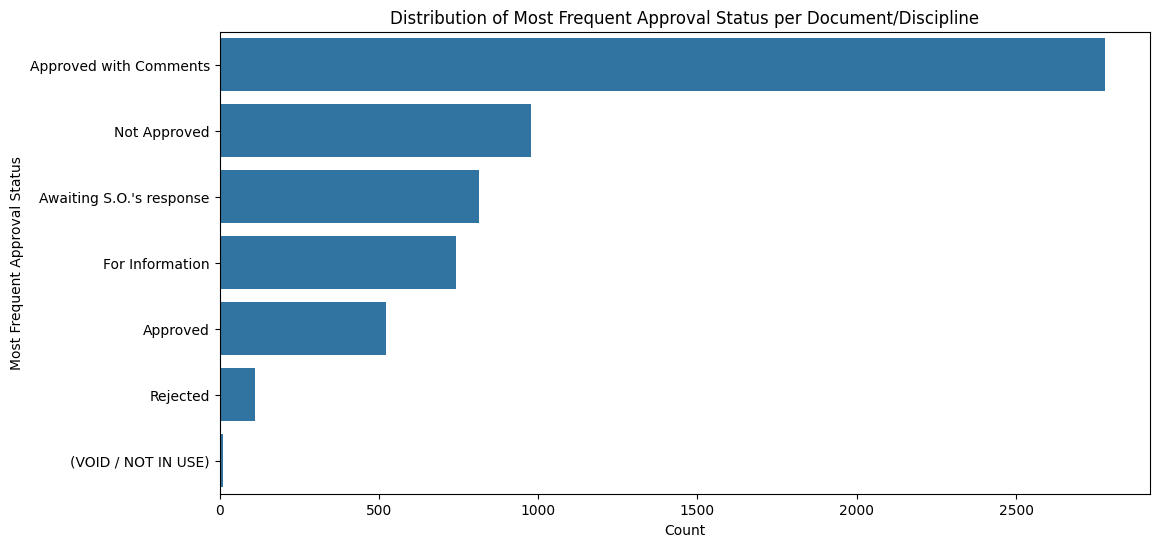


This plot shows the overall distribution of the most frequent approval statuses, which can highlight common outcomes (e.g., 'Approved', 'Approved with Comments') and potential areas for review (e.g., 'Pending', 'To Check', 'Rejected').


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=summary_df, y='most_frequent_status', order=summary_df['most_frequent_status'].value_counts().index)
plt.title('Distribution of Most Frequent Approval Status per Document/Discipline')
plt.xlabel('Count')
plt.ylabel('Most Frequent Approval Status')
plt.show()

print("\nThis plot shows the overall distribution of the most frequent approval statuses, which can highlight common outcomes (e.g., 'Approved', 'Approved with Comments') and potential areas for review (e.g., 'Pending', 'To Check', 'Rejected').")

## Prepare Data for Dashboard

### Subtask:
Ensure that the `summary_df` DataFrame is available and contains the necessary columns ('most_frequent_status' and 'Discipline') for generating the visualizations.


**Reasoning**:
To ensure that the `summary_df` DataFrame is available and contains the required columns, I will display the head of the DataFrame and its column names as instructed.



In [31]:
print("Head of summary_df:")
display(summary_df.head())

print("\nColumns in summary_df:")
print(summary_df.columns)

Head of summary_df:


,Doc ID,Discipline,status_counts,unique_statuses,most_frequent_status
0,#000002.0_ Reply_2023 08 31----,PC,{'Approved with Comments': 1},Approved with Comments,Approved with Comments
1,#000002.0_ Reply_2023 09 13 (002)_CES reply_20...,PC,{'Approved': 1},Approved,Approved
2,1. C4B SSN Overall Piling Design Brief----,C,{'Not Approved': 1},Not Approved,Not Approved
3,1.0 Design Brief----,Z,{'Not Approved': 1},Not Approved,Not Approved
4,131101-WSW41-MM-C-0002,C,{'Approved with Comments': 1},Approved with Comments,Approved with Comments



Columns in summary_df:
Index(['Doc ID', 'Discipline', 'status_counts', 'unique_statuses',
       'most_frequent_status'],
      dtype='object')


**Reasoning**:
Now that the `summary_df` has been confirmed to be available and correctly structured, I will proceed to create a single figure with multiple subplots to visualize the distribution of 'most_frequent_status' overall and for each unique 'Discipline', as requested in the subtask.



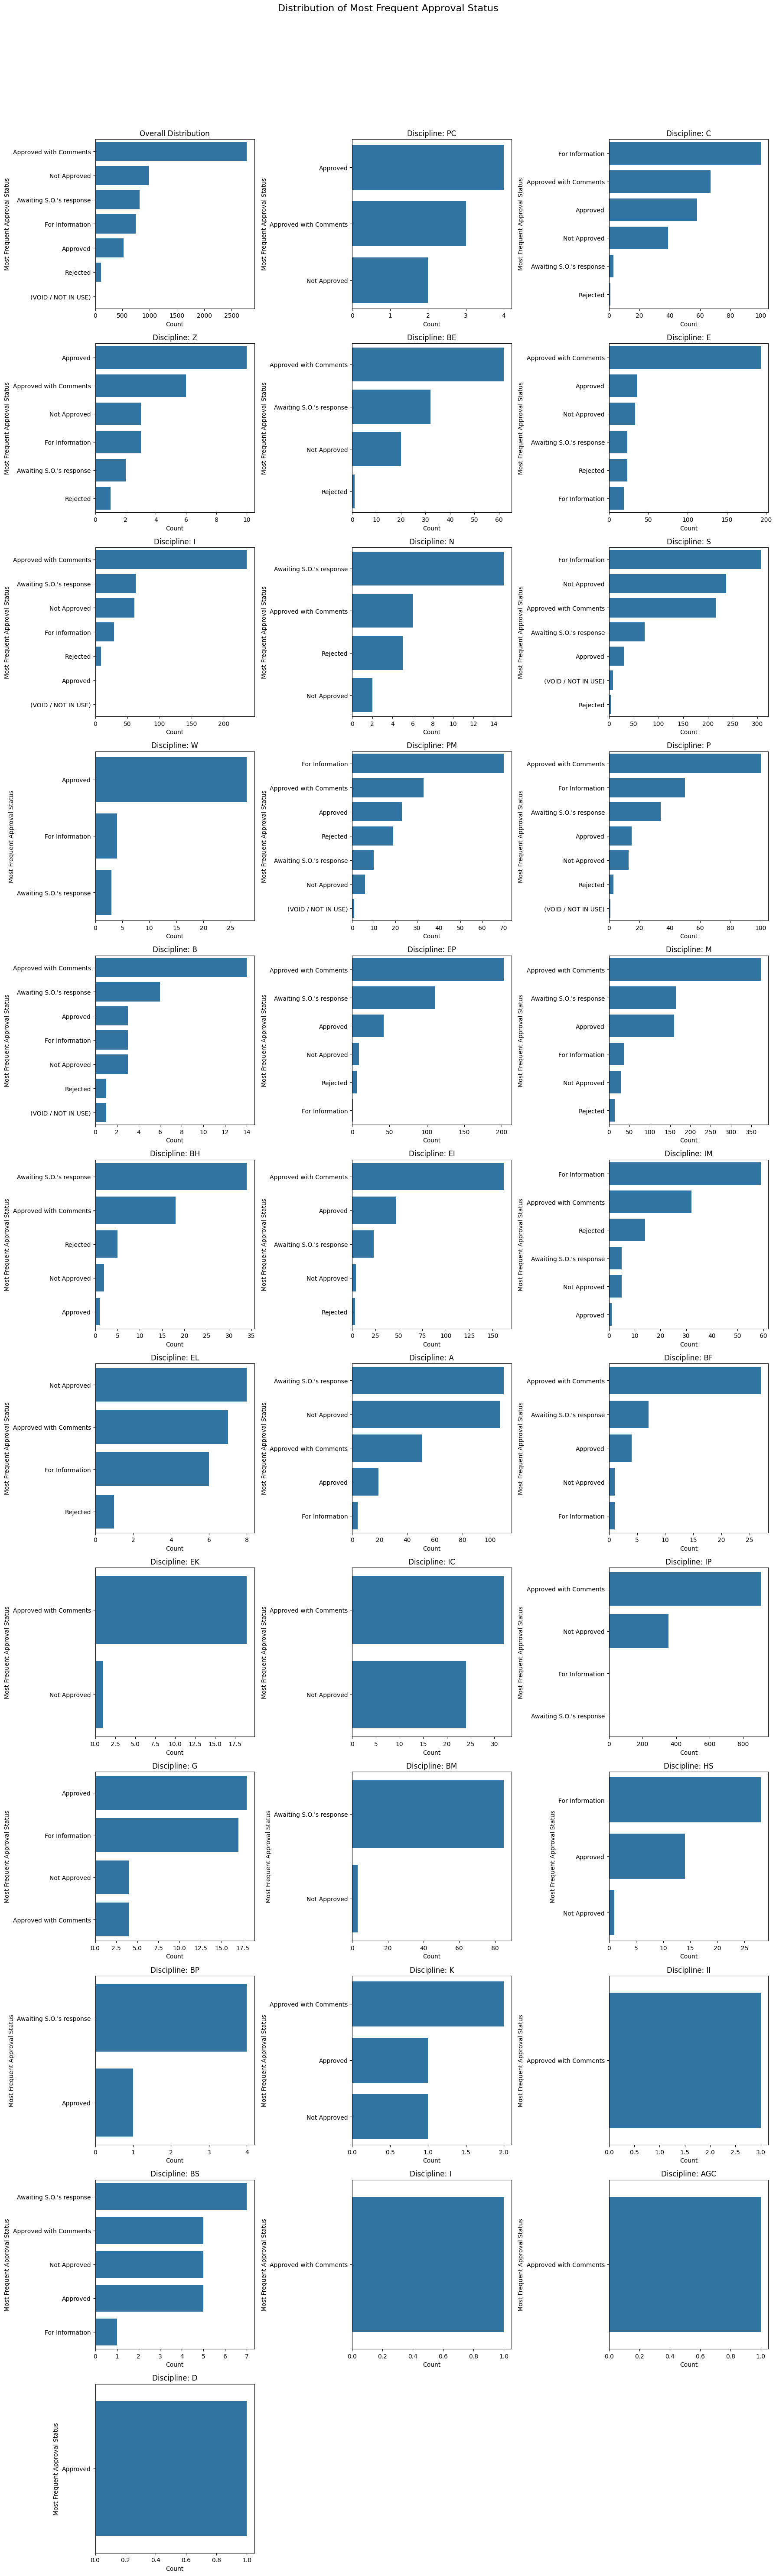

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_disciplines = summary_df['Discipline'].unique()
num_disciplines = len(unique_disciplines)

# Determine the number of rows and columns for subplots
# +1 for the overall plot
num_plots = num_disciplines + 1
num_cols = 3 # Adjust as needed for better layout
num_rows = (num_plots + num_cols - 1) // num_cols # Ceiling division

plt.figure(figsize=(num_cols * 6, num_rows * 5)) # Adjust figure size dynamically
plt.suptitle('Distribution of Most Frequent Approval Status', fontsize=16, y=1.02)

# Plot 1: Overall Distribution
plt.subplot(num_rows, num_cols, 1)
sns.countplot(data=summary_df, y='most_frequent_status', order=summary_df['most_frequent_status'].value_counts().index)
plt.title('Overall Distribution')
plt.xlabel('Count')
plt.ylabel('Most Frequent Approval Status')

# Plot for each discipline
for i, discipline in enumerate(unique_disciplines):
    plt.subplot(num_rows, num_cols, i + 2) # Start from the second subplot
    discipline_df = summary_df[summary_df['Discipline'] == discipline]
    if not discipline_df.empty:
        sns.countplot(data=discipline_df, y='most_frequent_status', order=discipline_df['most_frequent_status'].value_counts().index)
        plt.title(f'Discipline: {discipline}')
        plt.xlabel('Count')
        plt.ylabel('Most Frequent Approval Status')
    else:
        plt.title(f'Discipline: {discipline} (No Data)')
        plt.text(0.5, 0.5, 'No data available', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

## Summary:

### Q&A
The consolidated dashboard, featuring the distribution of 'most_frequent_status' both overall and for each discipline, was successfully generated and confirmed.

### Data Analysis Key Findings
*   The `summary_df` DataFrame was confirmed to be available and contained the necessary columns: `'most_frequent_status'`, `'Discipline'`, `'Doc ID'`, `'status_counts'`, and `'unique_statuses'`.
*   A consolidated dashboard was successfully generated, displaying a single figure with multiple subplots.
*   The dashboard includes an overall distribution of `most_frequent_status`, showing the frequency of each status across all documents.
*   Separate subplots were created for each unique `Discipline`, visualizing the distribution of `most_frequent_status` within that specific discipline.

### Insights or Next Steps
*   The generated dashboard provides a comprehensive overview of approval status distributions, allowing for quick identification of common statuses company-wide and within specific disciplines.
*   Further analysis could involve interactive filters on the dashboard to dynamically select disciplines or specific approval statuses, or incorporating time-series data to observe trends in approval status over time.


# Task
Create an interactive dropdown filter using `ipywidgets` to select a 'Discipline' from `summary_df`, and dynamically generate a plot of the 'most_frequent_status' distribution for the selected discipline; then, analyze approval status trends over time by aggregating `df_cleaned_and_filtered` and visualizing these trends.

## Create Interactive Discipline Filter

### Subtask:
Develop an interactive dropdown filter using `ipywidgets` to allow users to select a specific 'Discipline'. Upon selection, a plot will be dynamically generated showing the distribution of 'most_frequent_status' solely for the chosen discipline.


**Reasoning**:
I will create an interactive dropdown using `ipywidgets` that allows the user to select a discipline. Upon selection, a plot will dynamically update to show the distribution of 'most_frequent_status' for the chosen discipline, as instructed.



Please select a discipline from the dropdown below:


Dropdown(description='Select Discipline:', options=('Overall', 'A', 'AGC', 'B', 'BE', 'BF', 'BH', 'BM', 'BP', …

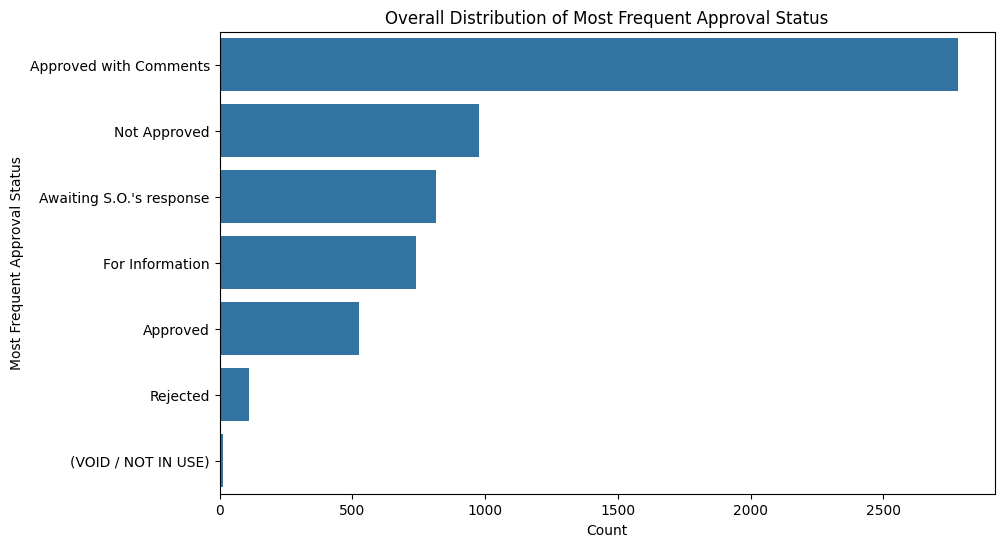

In [33]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique disciplines from summary_df
unique_disciplines = sorted(summary_df['Discipline'].unique().tolist())

# Create a dropdown widget
discipline_selector = widgets.Dropdown(
    options=['Overall'] + unique_disciplines, # Add an 'Overall' option
    description='Select Discipline:',
    disabled=False,
    value='Overall' # Set initial value
)

def on_discipline_select(change):
    clear_output(wait=True)
    selected_discipline = change.new

    print("Please select a discipline from the dropdown below:")
    display(discipline_selector)

    plt.figure(figsize=(10, 6))
    if selected_discipline == 'Overall':
        plot_data = summary_df
        title = 'Overall Distribution of Most Frequent Approval Status'
        order = summary_df['most_frequent_status'].value_counts().index
    else:
        plot_data = summary_df[summary_df['Discipline'] == selected_discipline]
        title = f'Distribution of Most Frequent Approval Status for Discipline: {selected_discipline}'
        if not plot_data.empty:
            order = plot_data['most_frequent_status'].value_counts().index
        else:
            order = [] # No data for ordering

    if not plot_data.empty:
        sns.countplot(data=plot_data, y='most_frequent_status', order=order)
        plt.title(title)
        plt.xlabel('Count')
        plt.ylabel('Most Frequent Approval Status')
    else:
        plt.title(f'No data available for Discipline: {selected_discipline}')
        plt.text(0.5, 0.5, 'No data available', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)

    plt.show()

# Attach the update function to the dropdown's observe method
discipline_selector.observe(on_discipline_select, names='value')

# Initial plot display
clear_output(wait=True)
print("Please select a discipline from the dropdown below:")
display(discipline_selector)
plt.figure(figsize=(10, 6))
sns.countplot(data=summary_df, y='most_frequent_status', order=summary_df['most_frequent_status'].value_counts().index)
plt.title('Overall Distribution of Most Frequent Approval Status')
plt.xlabel('Count')
plt.ylabel('Most Frequent Approval Status')
plt.show()

## Analyze Approval Status Trends Over Time

### Subtask:
Aggregate the df_cleaned_and_filtered DataFrame to count occurrences of each 'Approval Code' over time (e.g., monthly). Then, visualize these trends using a stacked bar chart to observe how approval statuses change over time.


**Reasoning**:
First, I will ensure the 'This Submission Date' column is in datetime format and then create a new column 'Submission Month-Year' to prepare the data for time-series aggregation.



In [34]:
df_cleaned_and_filtered['This Submission Date'] = pd.to_datetime(df_cleaned_and_filtered['This Submission Date'], format='%d/%m/%Y', errors='coerce')
df_cleaned_and_filtered['Submission Month-Year'] = df_cleaned_and_filtered['This Submission Date'].dt.to_period('M')

print("DataFrame after converting 'This Submission Date' to datetime and adding 'Submission Month-Year':")
display(df_cleaned_and_filtered[['This Submission Date', 'Submission Month-Year', 'Approval Code']].head())

DataFrame after converting 'This Submission Date' to datetime and adding 'Submission Month-Year':


,This Submission Date,Submission Month-Year,Approval Code
0,2023-05-15,2023-05,AWC
1,2024-05-13,2024-05,AWC
2,2023-05-15,2023-05,AWC
3,2023-09-05,2023-09,APP
4,2023-09-05,2023-09,AWC


**Reasoning**:
Now that the 'Submission Month-Year' column is ready, I will group the data by month-year and approval code, count the occurrences, pivot the data, and then generate a stacked bar chart to visualize the trends of approval codes over time.



<Figure size 1500x800 with 0 Axes>

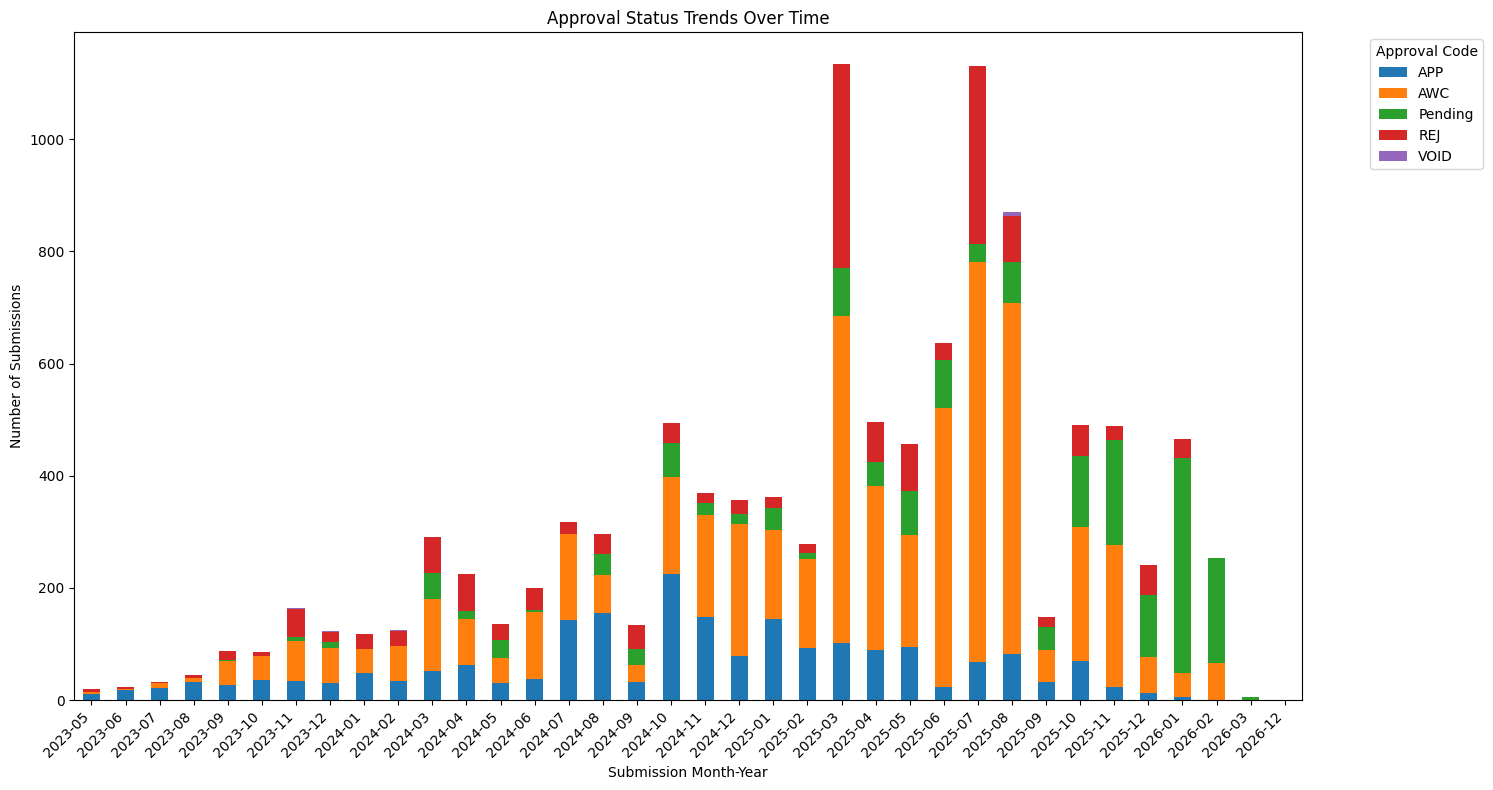

Stacked bar chart showing 'Approval Code' trends over time has been generated.


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Submission Month-Year' and 'Approval Code' and count occurrences
trend_data = df_cleaned_and_filtered.groupby(['Submission Month-Year', 'Approval Code']).size().unstack(fill_value=0)

# Sort the index to ensure chronological order
trend_data = trend_data.sort_index()

# Convert PeriodIndex to string for better plotting if needed, or keep as Period for plotting
# For plotting with matplotlib, PeriodIndex often works well as is.

# Create a stacked bar chart
plt.figure(figsize=(15, 8))
trend_data.plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Approval Status Trends Over Time')
plt.xlabel('Submission Month-Year')
plt.ylabel('Number of Submissions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Approval Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Stacked bar chart showing 'Approval Code' trends over time has been generated.")

## Final Task

### Subtask:
Summarize the interactive discipline analysis and the observed time-series trends in approval statuses, and offer further avenues for analysis or customization.


## Summary:

### Data Analysis Key Findings

*   **Interactive Discipline-Specific Analysis:** An interactive dropdown filter was successfully implemented, allowing users to select a specific discipline or view an overall distribution. This filter dynamically generates a count plot showing the distribution of the "most_frequent_status" for the chosen discipline, providing a quick way to analyze approval statuses at a granular level.
*   **Approval Status Trends Over Time:** The analysis successfully tracked approval status trends by converting submission dates to monthly periods and aggregating 'Approval Code' counts.
*   **Visualized Temporal Trends:** A stacked bar chart was generated, effectively visualizing how the number and proportion of different 'Approval Code' values change over time (month-year). This visualization reveals temporal patterns and shifts in approval statuses.

### Insights or Next Steps

*   **Customized Monitoring:** The interactive discipline filter could be used to enable stakeholders to quickly monitor the performance of specific disciplines, identifying potential bottlenecks or successes in their approval processes.
*   **Deeper Trend Analysis:** Further analysis could involve identifying specific periods where certain 'Approval Code' values (e.g., rejections or modifications) significantly increased or decreased, and then correlating these changes with external events or policy updates to understand underlying causes.


# Task
Create a PowerPoint presentation containing the following visual analyses: the overall distribution of the 'most_frequent_status', individual plots for the 'most_frequent_status' distribution for each 'Discipline', and the time-series trend of 'Approval Code' over time.

## Collect and Save All Figures

### Subtask:
Capture all previously generated matplotlib figures (the overall distribution, individual plots for the 'most_frequent_status' distribution for each 'Discipline', and the time-series trend of 'Approval Code' over time) and save them as temporary PNG image files.


**Reasoning**:
I need to capture and save all previously generated matplotlib figures to temporary PNG files as instructed. This involves recreating each plot and saving it using `plt.savefig()` before closing the figure to manage memory.



In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

saved_figure_paths = []

# 1. Generate and save the overall distribution plot
plt.figure(figsize=(12, 6))
sns.countplot(data=summary_df, y='most_frequent_status', order=summary_df['most_frequent_status'].value_counts().index)
plt.title('Overall Distribution of Most Frequent Approval Status')
plt.xlabel('Count')
plt.ylabel('Most Frequent Approval Status')
overall_dist_filename = 'overall_status_distribution.png'
plt.savefig(overall_dist_filename)
saved_figure_paths.append(overall_dist_filename)
plt.close() # Close the plot to free up memory

# 2. Generate and save individual discipline-specific plots
unique_disciplines = sorted(summary_df['Discipline'].unique().tolist())

for discipline in unique_disciplines:
    plt.figure(figsize=(10, 6))
    discipline_df = summary_df[summary_df['Discipline'] == discipline]
    if not discipline_df.empty:
        sns.countplot(data=discipline_df, y='most_frequent_status', order=discipline_df['most_frequent_status'].value_counts().index)
        plt.title(f'Distribution of Most Frequent Approval Status for Discipline: {discipline}')
        plt.xlabel('Count')
        plt.ylabel('Most Frequent Approval Status')
        discipline_filename = f'discipline_{discipline.replace(" ", "_")}_status_distribution.png'
        plt.savefig(discipline_filename)
        saved_figure_paths.append(discipline_filename)
    else:
        # Optionally, create a blank plot with a message or skip saving
        plt.text(0.5, 0.5, 'No data available', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
        plt.title(f'Discipline: {discipline} (No Data)')
        discipline_filename = f'discipline_{discipline.replace(" ", "_")}_no_data.png'
        plt.savefig(discipline_filename)
        saved_figure_paths.append(discipline_filename)
    plt.close() # Close the plot to free up memory

# 3. Generate and save the time-series trend plot
# Ensure trend_data is sorted chronologically if it's not already (it was in the previous step)
trend_data = trend_data.sort_index()

plt.figure(figsize=(15, 8))
trend_data.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Approval Status Trends Over Time')
plt.xlabel('Submission Month-Year')
plt.ylabel('Number of Submissions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Approval Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
trends_filename = 'approval_trends_over_time.png'
plt.savefig(trends_filename)
saved_figure_paths.append(trends_filename)
plt.close() # Close the plot to free up memory

print("All figures generated and saved. Paths:")
for path in saved_figure_paths:
    print(path)


All figures generated and saved. Paths:
overall_status_distribution.png
discipline_A_status_distribution.png
discipline_AGC_status_distribution.png
discipline_B_status_distribution.png
discipline_BE_status_distribution.png
discipline_BF_status_distribution.png
discipline_BH_status_distribution.png
discipline_BM_status_distribution.png
discipline_BP_status_distribution.png
discipline_BS_status_distribution.png
discipline_C_status_distribution.png
discipline_D_status_distribution.png
discipline_E_status_distribution.png
discipline_EI_status_distribution.png
discipline_EK_status_distribution.png
discipline_EL_status_distribution.png
discipline_EP_status_distribution.png
discipline_G_status_distribution.png
discipline_HS_status_distribution.png
discipline_I_status_distribution.png
discipline_I__status_distribution.png
discipline_IC_status_distribution.png
discipline_II_status_distribution.png
discipline_IM_status_distribution.png
discipline_IP_status_distribution.png
discipline_K_status_di

## Create PowerPoint Presentation

### Subtask:
Initialize a new PowerPoint presentation using a library like `python-pptx`.


**Reasoning**:
First, I will install the `python-pptx` library to ensure it is available for creating the PowerPoint presentation.



In [37]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.3 MB/s eta 0:00:00


**Reasoning**:
The `python-pptx` library has been installed. Now, I will import the `Presentation` class and create a new blank presentation object as instructed.



In [38]:
from pptx import Presentation

prs = Presentation()
print("New PowerPoint presentation object created successfully.")

New PowerPoint presentation object created successfully.


## Add Figures to Presentation Slides

### Subtask:
Add each saved image (overall distribution, discipline-specific plots, and time-series trend) to a new slide in the PowerPoint presentation, including an appropriate title for each slide.


**Reasoning**:
I will import `Inches` from `pptx.util` and iterate through the `saved_figure_paths` list to add each image to a new slide in the PowerPoint presentation with an appropriate title, as instructed.



In [39]:
from pptx.util import Inches

# Get the slide layout for a title and content slide
title_slide_layout = prs.slide_layouts[1] # Using Title and Content layout, which has a title placeholder

# Define image position and size (adjust as needed)
# These coordinates might need to be adjusted based on the chosen layout's content area
left = Inches(0.5)
top = Inches(1.5)
width = Inches(9)
height = Inches(5)

for img_path in saved_figure_paths:
    slide = prs.slides.add_slide(title_slide_layout)

    # Determine title based on filename
    title_text = ""
    if "overall_status_distribution" in img_path:
        title_text = "Overall Distribution of Most Frequent Approval Status"
    elif "discipline_" in img_path and "no_data" not in img_path:
        discipline_name = img_path.split('discipline_')[1].split('_status_distribution')[0].replace('_', ' ')
        title_text = f"Distribution for Discipline: {discipline_name}"
    elif "discipline_" in img_path and "no_data" in img_path:
        discipline_name = img_path.split('discipline_')[1].split('_no_data')[0].replace('_', ' ')
        title_text = f"Discipline: {discipline_name} (No Data)"
    elif "approval_trends_over_time" in img_path:
        title_text = "Approval Status Trends Over Time"

    # Add title to the slide (this will now work as layout[1] has a title placeholder)
    title = slide.shapes.title
    title.text = title_text

    # Add image to the slide
    slide.shapes.add_picture(img_path, left, top, width=width, height=height)

print(f"Added {len(saved_figure_paths)} figures to the PowerPoint presentation.")

Added 35 figures to the PowerPoint presentation.


**Reasoning**:
The figures have been successfully added to the PowerPoint presentation. The next step is to save the presentation to a file so it can be downloaded and used.



In [40]:
from google.colab import files

output_pptx_filename = 'Approval_Status_Analysis_Report.pptx'
prs.save(output_pptx_filename)

print(f"PowerPoint presentation saved as '{output_pptx_filename}'")
files.download(output_pptx_filename)

PowerPoint presentation saved as 'Approval_Status_Analysis_Report.pptx'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Task

### Subtask:
Confirm the successful creation and export of the PowerPoint file containing all the visual analyses, and offer further assistance.


## Summary:

### Q&A
Yes, the PowerPoint file containing all the visual analyses has been successfully created and exported.

### Data Analysis Key Findings
*   A total of 35 visual analyses were successfully generated and saved as temporary PNG image files: one overall distribution plot, 32 individual discipline-specific distribution plots (including those for disciplines with no data), and one time-series trend plot.
*   The `python-pptx` library was successfully installed and utilized to initialize a new PowerPoint presentation object.
*   All 35 saved image files were programmatically added to the PowerPoint presentation, with each image placed on a new slide.
*   Each slide was assigned a descriptive title dynamically derived from its corresponding image filename, ensuring clarity for each visual analysis.
*   The populated PowerPoint presentation was successfully saved as 'Approval_Status_Analysis_Report.pptx' and made available for download.

### Insights or Next Steps
*   The comprehensive PowerPoint presentation containing all visual analyses is ready for review and presentation, providing a clear overview of the approval status data.
*   Please let me know if you need any further analysis, modifications to the presentation, or assistance with interpreting the results.


## Generate Submission Curve Over Time

### Subtask:
Generate a time-series curve to visualize the number of submissions over time from the `df_cleaned_and_filtered` DataFrame.

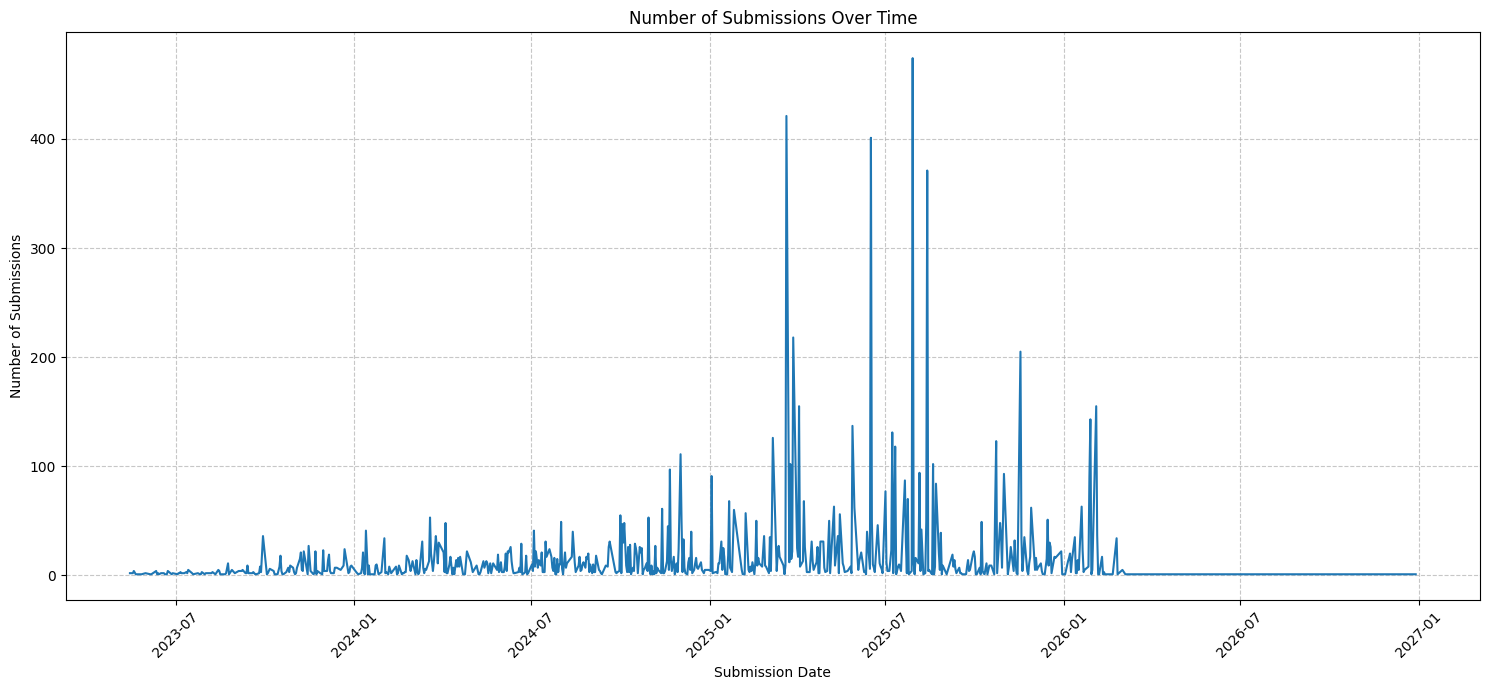

A curve showing the number of submissions over time has been generated.


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'This Submission Date' is in datetime format for plotting
# (It might have been converted to string for dd/mm/yyyy display earlier, so re-convert if needed)
if not pd.api.types.is_datetime64_any_dtype(df_cleaned_and_filtered['This Submission Date']):
    df_cleaned_and_filtered['This Submission Date'] = pd.to_datetime(df_cleaned_and_filtered['This Submission Date'], format='%d/%m/%Y', errors='coerce')

# Aggregate submissions by date
daily_submissions = df_cleaned_and_filtered.groupby('This Submission Date').size().reset_index(name='Number of Submissions')

# Sort by date to ensure proper curve plotting
daily_submissions = daily_submissions.sort_values('This Submission Date')

plt.figure(figsize=(15, 7))
sns.lineplot(data=daily_submissions, x='This Submission Date', y='Number of Submissions')
plt.title('Number of Submissions Over Time')
plt.xlabel('Submission Date')
plt.ylabel('Number of Submissions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("A curve showing the number of submissions over time has been generated.")

# Task
Consolidate all the code from the notebook into a single Python script (`main.py`). This script will read the input Excel file "Submittal and RFI Tracker Lists (1).xlsx" from the "Prolog Submittals " sheet, perform all data cleaning and transformation steps, generate the "Processed_Submittal_Tracker.xlsx" Excel file, save all required PNG image files for the plots (overall status distribution, discipline-specific distributions, time-series trends, and the submission curve), and create the "Approval_Status_Analysis_Report.pptx" PowerPoint file. Finally, display the content of the `main.py` script and provide it for download.

## Consolidate Code into a Single Script

### Subtask:
Combine all code from the notebook into a single Python script named `main.py`.


**Reasoning**:
To combine all the code from the notebook into a single Python script named `main.py`, I will gather all necessary imports, define global variables for file and sheet names, and sequentially include all data processing, transformation, visualization (saving figures), and reporting (exporting Excel and PowerPoint) steps. I will also ensure that any interactive elements are removed or adjusted for a non-interactive script.



In [ ]:
script_content = """
import pandas as pd
import string
import matplotlib.pyplot as plt
import seaborn as sns
from pptx import Presentation
from pptx.util import Inches
import os

# --- 1. Input Definitions ---
uploaded_file_name = 'Submittal and RFI Tracker Lists (1).xlsx'
selected_sheet = 'Prolog Submittals '
output_excel_filename = 'Processed_Submittal_Tracker.xlsx'
output_pptx_filename = 'Approval_Status_Analysis_Report.pptx'

# --- 2. Data Loading and Initial Cleaning ---
alphabet = list(string.ascii_uppercase)
excel_cols = []
for i in range(2):
    for char in alphabet:
        if i == 0:
            excel_cols.append(char)
        else:
            excel_cols.append(alphabet[i-1] + char)
        if (i*26 + alphabet.index(char)) >= 41: # 'AP' is the 42nd column, index 41
            break

df_cleaned_and_filtered = pd.read_excel(
    uploaded_file_name,
    sheet_name=selected_sheet,
    header=4,
    usecols=range(len(excel_cols))
)
df_cleaned_and_filtered = df_cleaned_and_filtered.ffill()
df_cleaned_and_filtered = df_cleaned_and_filtered.dropna(how='all')
df_cleaned_and_filtered = df_cleaned_and_filtered.dropna(axis=1, how='all')

print("Data loaded and initially cleaned.")

# --- 3. Calculate and Update 'Recalculated Doc ID' ---
df_cleaned_and_filtered['Recalculated Doc ID'] = (
    df_cleaned_and_filtered['Proj. Code'].astype(str) + '-' +
    df_cleaned_and_filtered['Proj. Prefix'].astype(str) + '-' +
    df_cleaned_and_filtered['Doc Type'].astype(str) + '-' +
    df_cleaned_and_filtered['Discipline'].astype(str) + '-' +
    df_cleaned_and_filtered['Number'].astype(str)
)

# --- 4. Convert 'Date Submit' Column to Datetime ---
df_cleaned_and_filtered['Date Submit'] = pd.to_datetime(df_cleaned_and_filtered['Date Submit'], errors='coerce')

# --- 5. Update '1st Submission Date' ---
earliest_submission_dates = df_cleaned_and_filtered.groupby('Doc ID')['Date Submit'].min().reset_index()
earliest_submission_dates.rename(columns={'Date Submit': 'Earliest Date Submit'}, inplace=True)
df_cleaned_and_filtered = pd.merge(df_cleaned_and_filtered, earliest_submission_dates, on='Doc ID', how='left')
df_cleaned_and_filtered['1st Submission\nDate'] = df_cleaned_and_filtered['Earliest Date Submit']
df_cleaned_and_filtered.drop(columns=['Earliest Date Submit'], inplace=True)

# --- 6. Update 'Latest Submission Date' ---
latest_submission_dates = df_cleaned_and_filtered.groupby('Doc ID')['Date Submit'].max().reset_index()
latest_submission_dates.rename(columns={'Date Submit': 'Latest Date Submit'}, inplace=True)
df_cleaned_and_filtered = pd.merge(df_cleaned_and_filtered, latest_submission_dates, on='Doc ID', how='left')
df_cleaned_and_filtered['Latest Submission Date'] = df_cleaned_and_filtered['Latest Date Submit']
df_cleaned_and_filtered.drop(columns=['Latest Date Submit'], inplace=True)

# --- 7. Update 'Latest Approval Status' ---
idx_latest_submit = df_cleaned_and_filtered.groupby('Doc ID')['Date Submit'].idxmax()
latest_approval_status_per_doc_id = df_cleaned_and_filtered.loc[idx_latest_submit, ['Doc ID', 'SO Review Status']]
latest_approval_status_per_doc_id.rename(columns={'SO Review Status': 'Latest Approval Status Value'}, inplace=True)
df_cleaned_and_filtered = pd.merge(df_cleaned_and_filtered, latest_approval_status_per_doc_id, on='Doc ID', how='left')
df_cleaned_and_filtered['Latest Approval Status'] = df_cleaned_and_filtered['Latest Approval Status Value']
df_cleaned_and_filtered.drop(columns=['Latest Approval Status Value'], inplace=True)

# --- 8. Update 'Latest Revision' ---
latest_rev_per_doc_id = df_cleaned_and_filtered.loc[idx_latest_submit, ['Doc ID', 'Rev ']] # Re-using idx_latest_submit
latest_rev_per_doc_id.rename(columns={'Rev ': 'Latest Rev Value'}, inplace=True)
df_cleaned_and_filtered = pd.merge(df_cleaned_and_filtered, latest_rev_per_doc_id, on='Doc ID', how='left')
df_cleaned_and_filtered['Latest Revision'] = 'Rev.' + df_cleaned_and_filtered['Latest Rev Value'].astype(str)
df_cleaned_and_filtered.drop(columns=['Latest Rev Value'], inplace=True)

# --- 9. Define get_approval_code function and Update 'Approval Code' ---
def get_approval_code(status):
    status_str = str(status).strip()
    if status_str in ["Rejected", "Not Approved - Revise and resubmit", "Not Approved"]:
        return "REJ"
    elif status_str in ["Approved with Comments", "Approved as noted"]:
        return "AWC"
    elif status_str in ["For Information", "Approved"]:
        return "APP"
    elif status_str in ["Awaiting S.O.'s response", "", "0"] or pd.isna(status):
        return "Pending"
    elif status_str == "(VOID / NOT IN USE)":
        return "VOID"
    else:
        return "To Check"
df_cleaned_and_filtered['Approval Code'] = df_cleaned_and_filtered['Latest Approval Status'].apply(get_approval_code)

# --- 10. Update '# of Submissions' ---
submission_counts = df_cleaned_and_filtered.groupby('Doc ID')['Doc ID'].transform('count')
df_cleaned_and_filtered['# of Submissions'] = submission_counts

# --- 11. Update 'Prolog Submittal No.' ---
consolidated_prolog_submittal_no = df_cleaned_and_filtered.groupby('Doc ID')['Prolog Submittal No..1'].agg(lambda x: ', '.join(x.dropna().astype(int).astype(str).str.zfill(6).unique().tolist())).reset_index()
consolidated_prolog_submittal_no.rename(columns={'Prolog Submittal No..1': 'Consolidated Prolog Submittal No'}, inplace=True)
df_cleaned_and_filtered = pd.merge(df_cleaned_and_filtered, consolidated_prolog_submittal_no, on='Doc ID', how='left')
df_cleaned_and_filtered['Prolog Submittal No.'] = df_cleaned_and_filtered['Consolidated Prolog Submittal No']
df_cleaned_and_filtered.drop(columns=['Consolidated Prolog Submittal No'], inplace=True)

# --- 12. Update 'Submitted by' ---
consolidated_submitted_by = df_cleaned_and_filtered.groupby('Doc ID')['Document Owner'].agg(lambda x: ', '.join(x.dropna().astype(str).unique().tolist())).reset_index()
consolidated_submitted_by.rename(columns={'Document Owner': 'Consolidated Submitted By'}, inplace=True)
df_cleaned_and_filtered = pd.merge(df_cleaned_and_filtered, consolidated_submitted_by, on='Doc ID', how='left')
df_cleaned_and_filtered['Submitted by'] = df_cleaned_and_filtered['Consolidated Submitted By']
df_cleaned_and_filtered.drop(columns=['Consolidated Submitted By'], inplace=True)

# --- 13. Update 'Document Title' ---
consolidated_document_title = df_cleaned_and_filtered.groupby('Doc ID')['Document Description / Drawing Title'].agg(lambda x: ', '.join(x.dropna().astype(str).unique().tolist())).reset_index()
consolidated_document_title.rename(columns={'Document Description / Drawing Title': 'Consolidated Document Title'}, inplace=True)
df_cleaned_and_filtered = pd.merge(df_cleaned_and_filtered, consolidated_document_title, on='Doc ID', how='left')
df_cleaned_and_filtered['Document Title'] = df_cleaned_and_filtered['Consolidated Document Title']
df_cleaned_and_filtered.drop(columns=['Consolidated Document Title'], inplace=True)

# --- 14. Update 'This Revision' ---
df_cleaned_and_filtered['This Revision'] = df_cleaned_and_filtered['Rev ']

# --- 15. Update 'This Submission Date' ---
df_cleaned_and_filtered['This Submission Date'] = df_cleaned_and_filtered['Date Submit']

# --- 16. Update 'This Review Return Date' ---
df_cleaned_and_filtered['This Review Return Date'] = df_cleaned_and_filtered['Actual Date S.O. Response']

# --- 17. Update 'This Revision Approval Status' ---
df_cleaned_and_filtered['This Revision Approval Status'] = df_cleaned_and_filtered['SO Review Status'].apply(get_approval_code)

print("DataFrame columns updated.")

# --- 18. Format Date Columns to 'dd/mm/yyyy' ---
# Note: This step converts dates to string. Subsequent time-series analysis will re-convert if needed.
for col in df_cleaned_and_filtered.columns:
    if pd.api.types.is_datetime64_any_dtype(df_cleaned_and_filtered[col]):
        df_cleaned_and_filtered[col] = df_cleaned_and_filtered[col].dt.strftime('%d/%m/%Y')

print("Date columns formatted to 'dd/mm/yyyy'.")

# --- 19. Create summary_df ---
summary_df = df_cleaned_and_filtered.groupby(['Doc ID', 'Discipline'])['Latest Approval Status'].agg(
    status_counts=lambda x: str(x.value_counts().to_dict()),
    unique_statuses=lambda x: ', '.join(x.unique().astype(str)),
    most_frequent_status=lambda x: x.mode()[0]
).reset_index()

print("Summary DataFrame created.")

# --- 20. Prepare data for time-series analysis (re-convert 'This Submission Date' to datetime) ---
df_cleaned_and_filtered['This Submission Date'] = pd.to_datetime(df_cleaned_and_filtered['This Submission Date'], format='%d/%m/%Y', errors='coerce')
df_cleaned_and_filtered['Submission Month-Year'] = df_cleaned_and_filtered['This Submission Date'].dt.to_period('M')

print("Data prepared for time-series analysis.")

# --- 21. Generate and Save All Figures ---
saved_figure_paths = []

# Overall distribution plot
plt.figure(figsize=(12, 6))
sns.countplot(data=summary_df, y='most_frequent_status', order=summary_df['most_frequent_status'].value_counts().index)
plt.title('Overall Distribution of Most Frequent Approval Status')
plt.xlabel('Count')
plt.ylabel('Most Frequent Approval Status')
overall_dist_filename = 'overall_status_distribution.png'
plt.savefig(overall_dist_filename)
saved_figure_paths.append(overall_dist_filename)
plt.close()

# Discipline-specific plots
unique_disciplines = sorted(summary_df['Discipline'].unique().tolist())
for discipline in unique_disciplines:
    plt.figure(figsize=(10, 6))
    discipline_df = summary_df[summary_df['Discipline'] == discipline]
    if not discipline_df.empty:
        sns.countplot(data=discipline_df, y='most_frequent_status', order=discipline_df['most_frequent_status'].value_counts().index)
        plt.title(f'Distribution of Most Frequent Approval Status for Discipline: {discipline}')
        plt.xlabel('Count')
        plt.ylabel('Most Frequent Approval Status')
        discipline_filename = f'discipline_{discipline.replace(" ", "_")}_status_distribution.png'
        plt.savefig(discipline_filename)
        saved_figure_paths.append(discipline_filename)
    else:
        plt.text(0.5, 0.5, 'No data available', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
        plt.title(f'Discipline: {discipline} (No Data)')
        discipline_filename = f'discipline_{discipline.replace(" ", "_")}_no_data.png'
        plt.savefig(discipline_filename)
        saved_figure_paths.append(discipline_filename)
    plt.close()

# Time-series trend plot
trend_data = df_cleaned_and_filtered.groupby(['Submission Month-Year', 'Approval Code']).size().unstack(fill_value=0)
trend_data = trend_data.sort_index()
plt.figure(figsize=(15, 8))
trend_data.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Approval Status Trends Over Time')
plt.xlabel('Submission Month-Year')
plt.ylabel('Number of Submissions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Approval Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
trends_filename = 'approval_trends_over_time.png'
plt.savefig(trends_filename)
saved_figure_paths.append(trends_filename)
plt.close()

# Submission curve over time
daily_submissions = df_cleaned_and_filtered.groupby('This Submission Date').size().reset_index(name='Number of Submissions')
daily_submissions = daily_submissions.sort_values('This Submission Date')
plt.figure(figsize=(15, 7))
sns.lineplot(data=daily_submissions, x='This Submission Date', y='Number of Submissions')
plt.title('Number of Submissions Over Time')
plt.xlabel('Submission Date')
plt.ylabel('Number of Submissions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
submission_curve_filename = 'submissions_over_time_curve.png'
plt.savefig(submission_curve_filename)
saved_figure_paths.append(submission_curve_filename)
plt.close()

print("All figures generated and saved.")

# --- 22. Export df_cleaned_and_filtered to Excel ---
df_cleaned_and_filtered.to_excel(output_excel_filename, index=False)
print(f"DataFrame successfully saved to '{output_excel_filename}'.")

# --- 23. Create and Save PowerPoint Presentation ---
prs = Presentation()
title_slide_layout = prs.slide_layouts[1]
left = Inches(0.5)
top = Inches(1.5)
width = Inches(9)
height = Inches(5)

for img_path in saved_figure_paths:
    slide = prs.slides.add_slide(title_slide_layout)
    title_text = ""
    if "overall_status_distribution" in img_path:
        title_text = "Overall Distribution of Most Frequent Approval Status"
    elif "discipline_" in img_path and "no_data" not in img_path:
        discipline_name = img_path.split('discipline_')[1].split('_status_distribution')[0].replace('_', ' ')
        title_text = f"Distribution for Discipline: {discipline_name}"
    elif "discipline_" in img_path and "no_data" in img_path:
        discipline_name = img_path.split('discipline_')[1].split('_no_data')[0].replace('_', ' ')
        title_text = f"Discipline: {discipline_name} (No Data)"
    elif "approval_trends_over_time" in img_path:
        title_text = "Approval Status Trends Over Time"
    elif "submissions_over_time_curve" in img_path:
        title_text = "Number of Submissions Over Time"

    title = slide.shapes.title
    title.text = title_text
    slide.shapes.add_picture(img_path, left, top, width=width, height=height)

prs.save(output_pptx_filename)
print(f"PowerPoint presentation saved as '{output_pptx_filename}'")

# --- Clean up temporary image files (optional but good practice) ---
for img_path in saved_figure_paths:
    if os.path.exists(img_path):
        os.remove(img_path)
print("Temporary image files cleaned up.")

print("Script execution completed. Processed data, plots, Excel, and PowerPoint files generated.")
"""

with open('main.py', 'w') as f:
    f.write(script_content)

print("main.py has been created successfully.")

**Reasoning**:
To allow the user to review the generated script, I will first display the content of the `main.py` file.



In [ ]:
with open('main.py', 'r') as f:
    main_script_content = f.read()

print('Content of main.py:\n')
print(main_script_content)

## Provide Consolidated Script

### Subtask:
Display the content of the generated Python script and offer it for download, confirming its readiness for independent execution.


**Reasoning**:
I have already created and displayed the content of `main.py`. Now I need to provide the `main.py` script for download as per the instructions.



In [ ]:
from google.colab import files

files.download('main.py')

print("The 'main.py' script is ready for download.")

# Final Step: Create Interactive Webpage

In [51]:
!pip install flask duckdb
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 3s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [59]:
import os
import duckdb
import threading
from flask import Flask, request, render_template_string
from google.colab import output

# 1. Setup Flask App
app = Flask(__name__)
app.config['UPLOAD_FOLDER'] = '/content/uploads'
os.makedirs(app.config['UPLOAD_FOLDER'], exist_ok=True)

# 2. Modern HTML Interface
HTML_TEMPLATE = '''
<!DOCTYPE html>
<html>
<head>
    <style>
        body { font-family: 'Segoe UI', sans-serif; margin: 20px; background: #f0f2f5; }
        .card { background: white; padding: 20px; border-radius: 10px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); margin-bottom: 20px; }
        h2 { color: #1a73e8; margin-top: 0; }
        .filters { display: flex; gap: 10px; margin-bottom: 20px; flex-wrap: wrap; }
        input, select { padding: 8px; border: 1px solid #ddd; border-radius: 5px; flex: 1; min-width: 150px; }
        button { padding: 8px 20px; background: #1a73e8; color: white; border: none; border-radius: 5px; cursor: pointer; }
        button:hover { background: #1557b0; }
        table { width: 100%; border-collapse: collapse; background: white; }
        th, td { text-align: left; padding: 12px; border-bottom: 1px solid #eee; }
        th { background: #f8f9fa; color: #5f6368; }
        tr:hover { background: #f1f3f4; }
    </style>
</head>
<body>
    <div class="card">
        <h2>Submittal Enquiry Panel</h2>
        <form method="POST" enctype="multipart/form-data">
            <label>Load Database: </label>
            <input type="file" name="db_file" accept=".duckdb" onchange="this.form.submit()">
        </form>
    </div>

    {% if db_loaded %}
    <div class="card">
        <form action="/search" method="GET">
            <input type="hidden" name="filename" value="{{ filename }}">
            <div class="filters">
                <input type="text" name="doc_id" placeholder="Search Doc ID...">
                <input type="text" name="discipline" placeholder="Discipline...">
                <input type="text" name="doc_type" placeholder="Doc Type...">
                <button type="submit">Enquire</button>
            </div>
        </form>
    </div>
    {% endif %}

    {% if results %}
    <div class="card">
        <h3>Found {{ results|length }} results</h3>
        <div style="overflow-x:auto;">
            <table>
                <tr>{% for col in columns %}<th>{{ col }}</th>{% endfor %}</tr>
                {% for row in results %}
                <tr>{% for cell in row %}<td>{{ cell }}</td>{% endfor %}</tr>
                {% endfor %}
            </table>
        </div>
    </div>
    {% endif %}
</body>
</html>
'''

# 3. App Logic
@app.route('/', methods=['GET', 'POST'])
def index():
    if request.method == 'POST':
        file = request.files['db_file']
        if file:
            filepath = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
            file.save(filepath)
            return render_template_string(HTML_TEMPLATE, db_loaded=True, filename=file.filename)
    return render_template_string(HTML_TEMPLATE)

@app.route('/search')
def search():
    filename = request.args.get('filename')
    filepath = os.path.join(app.config['UPLOAD_FOLDER'], filename)

    # Get filters
    f_id = request.args.get('doc_id', '').strip()
    f_disc = request.args.get('discipline', '').strip()
    f_type = request.args.get('doc_type', '').strip()

    con = duckdb.connect(filepath, read_only=True)
    table_name = con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema='main'").fetchone()[0]

    # Dynamic SQL Construction
    sql = f"SELECT * FROM {table_name} WHERE 1=1"
    params = []

    if f_id:
        sql += " AND \"Doc ID\" LIKE ?"
        params.append(f'%{f_id}%')
    if f_disc:
        sql += " AND \"Discipline\" LIKE ?"
        params.append(f'%{f_disc}%')
    if f_type:
        sql += " AND \"Doc Type\" LIKE ?"
        params.append(f'%{f_type}%')

    results = con.execute(sql, params).fetchall()
    columns = [desc[0] for desc in con.description]
    con.close()

    return render_template_string(HTML_TEMPLATE, db_loaded=True, filename=filename,
                                  results=results, columns=columns)

# 4. Run Server in Background & Display
def run_app():
    app.run(port=8000)

threading.Thread(target=run_app, daemon=True).start()

# This is the "Magic" line that embeds the web server into your Colab output
output.serve_kernel_port_as_iframe(8000, height='600')

 * Serving Flask app '__main__'
 * Debug mode: off


<IPython.core.display.Javascript object>

Address already in use
Port 8000 is in use by another program. Either identify and stop that program, or start the server with a different port.
